Loading Ames Housing dataset...
Training Models...

--- Simple Linear Regression ---
MAE:  $38,341.20
RMSE: $58,471.76
R2:   0.5543

--- Multiple Linear Regression ---
MAE:  $18,362.37
RMSE: $29,445.53
R2:   0.8870

--- Polynomial Regression (Degree 2, Ridge Control) ---
MAE:  $22,652.52
RMSE: $34,723.64
R2:   0.8428

--- Decision Tree Regressor ---
MAE:  $25,902.81
RMSE: $40,786.65
R2:   0.7831

Generating diagnostic plots...


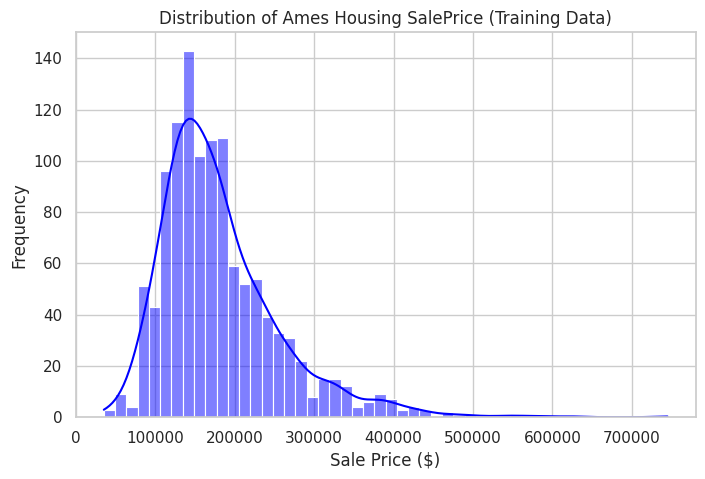

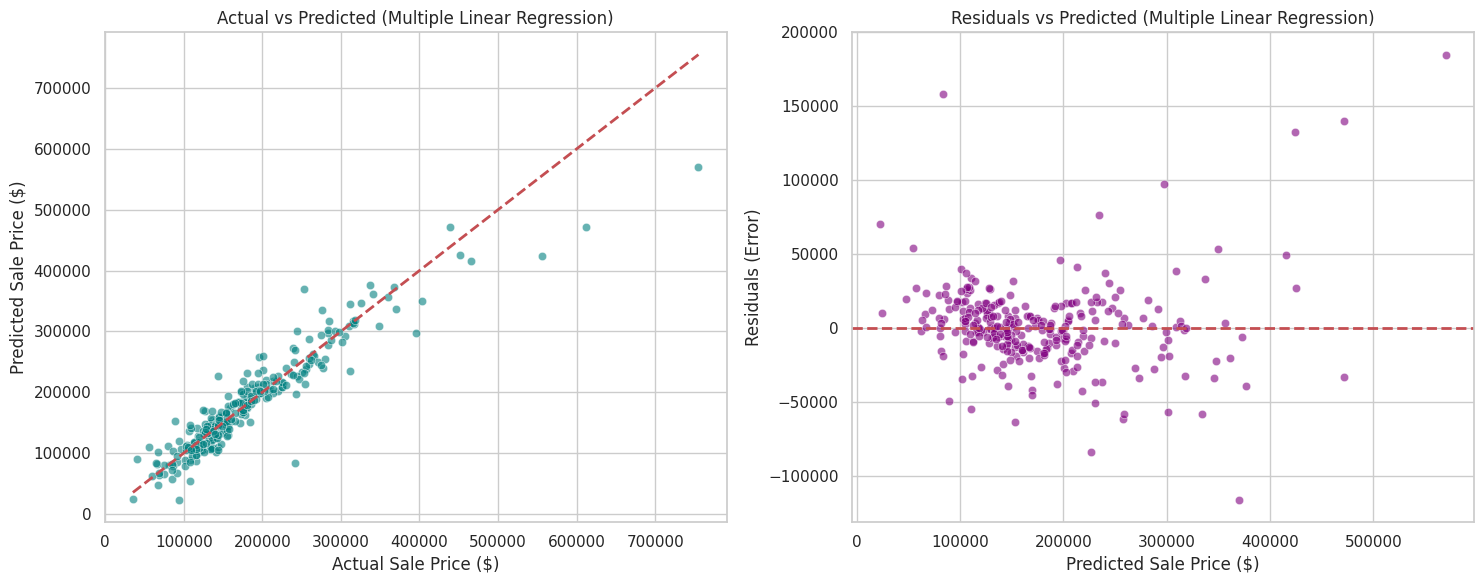

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

ames = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = ames.frame
target = 'SalePrice'

X = df.drop(columns=[target, 'Id'])
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

def evaluate_regressor(name, fitted_model, X_eval, y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)

    print(f"--- {name} ---")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2:   {r2:.4f}\n")
    return pred

simple_feature = 'GrLivArea'
simple_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LinearRegression())
])
simple_model.fit(X_train[[simple_feature]], y_train)

print("--- Simple Linear Regression ---")
simple_pred = simple_model.predict(X_test[[simple_feature]])
print(f"MAE:  ${mean_absolute_error(y_test, simple_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, simple_pred)):,.2f}")
print(f"R2:   {r2_score(y_test, simple_pred):.4f}\n")

linear_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
mult_linear_pred = evaluate_regressor("Multiple Linear Regression", linear_pipeline, X_test, y_test)

poly_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF']
poly_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
poly_pipe.fit(X_train[poly_features], y_train)
evaluate_regressor("Polynomial Regression (Degree 2, Ridge Control)", poly_pipe, X_test[poly_features], y_test)


tree_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeRegressor(max_depth=8, random_state=SEED))
])
tree_pipeline.fit(X_train, y_train)
evaluate_regressor("Decision Tree Regressor", tree_pipeline, X_test, y_test)

print("Generating diagnostic plots...")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(y_train, kde=True, bins=50, color='blue')
plt.title("Distribution of Ames Housing SalePrice (Training Data)")
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=y_test, y=mult_linear_pred, alpha=0.6, ax=axes[0], color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Sale Price ($)")
axes[0].set_ylabel("Predicted Sale Price ($)")
axes[0].set_title("Actual vs Predicted (Multiple Linear Regression)")

residuals = y_test - mult_linear_pred
sns.scatterplot(x=mult_linear_pred, y=residuals, alpha=0.6, ax=axes[1], color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted Sale Price ($)")
axes[1].set_ylabel("Residuals (Error)")
axes[1].set_title("Residuals vs Predicted (Multiple Linear Regression)")

plt.tight_layout()
plt.show()